In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from preprocessing import spacy_preprocessor, spacy_tokenizer
from helpfuncties import load_dataset

In [2]:
df = load_dataset()
X_text = df["Omschrijving"].astype(str)
y = df["Product"]

In [3]:
def make_domain_features(series: pd.Series) -> pd.DataFrame:
    s = series.fillna("").str.lower()

    auto_terms = r"auto|vehicle|car|dealership|dealer|auto loan|car loan|repossession|repo|drive time|honda|toyota|nissan|ford|gm|chrysler|santander|westlake|ally"
    bureau_terms = r"equifax|experian|transunion|credit report|credit file|inquiry|inquiries|report xxxx|fcra"
    collection_terms = r"debt|collection|collector|collect|fdcpa|validation|collection agency|attempting collect|owe|recovery"
    fraud_terms = r"identity theft|fraud|unauthorized|not mine|stolen identity"

    return pd.DataFrame({
        "has_auto_terms": s.str.contains(auto_terms, regex=True).astype(int),
        "has_creditbureau_terms": s.str_contains(bureau_terms, regex=True).astype(int) if hasattr(s, "str") else s.str.contains(bureau_terms, regex=True).astype(int),
        "has_collection_terms": s.str.contains(collection_terms, regex=True).astype(int),
        "fraud_flag": s.str.contains(fraud_terms, regex=True).astype(int),
    })

In [4]:
def make_domain_features(series: pd.Series) -> pd.DataFrame:
    s = series.fillna("").str.lower()

    auto_terms = r"auto|vehicle|car|dealership|dealer|auto loan|car loan|repossession|repo|drive time|honda|toyota|nissan|ford|gm|chrysler|santander|westlake|ally"
    bureau_terms = r"equifax|experian|transunion|credit report|credit file|inquiry|inquiries|report xxxx|fcra"
    collection_terms = r"debt|collection|collector|collect|fdcpa|validation|collection agency|attempting collect|owe|recovery"
    fraud_terms = r"identity theft|fraud|unauthorized|not mine|stolen identity"

    return pd.DataFrame({
        "has_auto_terms": s.str.contains(auto_terms, regex=True).astype(int),
        "has_creditbureau_terms": s.str.contains(bureau_terms, regex=True).astype(int),
        "has_collection_terms": s.str.contains(collection_terms, regex=True).astype(int),
        "fraud_flag": s.str.contains(fraud_terms, regex=True).astype(int),
    })

domain_df = make_domain_features(X_text)

# Combineer tekst + features in één DataFrame
X_full = pd.concat([X_text.rename("Omschrijving"), domain_df], axis=1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
text_tfidf = TfidfVectorizer(
    preprocessor=spacy_preprocessor,
    tokenizer=spacy_tokenizer,
    analyzer="word",
    token_pattern=None,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2"
)

feature_cols = ["has_auto_terms", "has_creditbureau_terms", "has_collection_terms", "fraud_flag"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_tfidf, "Omschrijving"),
        ("flags", StandardScaler(with_mean=False), feature_cols),
    ]
)

In [7]:
svc_pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

In [8]:
param_grid = {
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "features__text__ngram_range": [(1, 1), (1, 2)],  # unigrams vs uni+bi
    "features__text__max_df": [0.9, 0.95],
    "features__text__min_df": [2, 3],
}

grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Start GridSearch LinearSVC + domeinfeatures...")
grid.fit(X_train, y_train)

print("\nBeste parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Start GridSearch LinearSVC + domeinfeatures...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Beste parameters:
{'clf__C': 1.0, 'features__text__max_df': 0.9, 'features__text__min_df': 2, 'features__text__ngram_range': (1, 2)}


In [9]:
cv_scores = cross_val_score(
    best_model,
    X_train, y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
print(f"\nCV F1-macro (train): {cv_scores.mean():.3f}")
print("Per fold:", cv_scores)


CV F1-macro (train): 0.838
Per fold: [0.8397257  0.85270296 0.81488114 0.84599799 0.8369486 ]


In [16]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy test: {acc:.3f}")
print(f"F1-macro test: {f1_macro:.3f}")
print(f"F1-weighted test: {f1_weighted:.3f}")

print("\nClassification report LinearSVC + domeinfeatures en spaCy preprocessing:")
print(classification_report(y_test, y_pred, digits=2))


Accuracy test: 0.863
F1-macro test: 0.840
F1-weighted test: 0.862

Classification report LinearSVC + domeinfeatures en spaCy preprocessing:
                    precision    recall  f1-score   support

      Bankrekening       0.87      0.86      0.86       446
Consumentenkrediet       0.75      0.64      0.69       284
        Creditcard       0.83      0.85      0.84       564
         Hypotheek       0.92      0.95      0.94       994
           Incasso       0.85      0.87      0.86      1223
Kredietregistratie       0.86      0.83      0.85       934

          accuracy                           0.86      4445
         macro avg       0.85      0.83      0.84      4445
      weighted avg       0.86      0.86      0.86      4445



[[ 383    2   32   14    9    6]
 [   9  183   17   15   44   16]
 [  22    9  479    2   30   22]
 [  13    7    4  945   11   14]
 [  11   22   22   31 1070   67]
 [   4   22   23   16   93  776]]


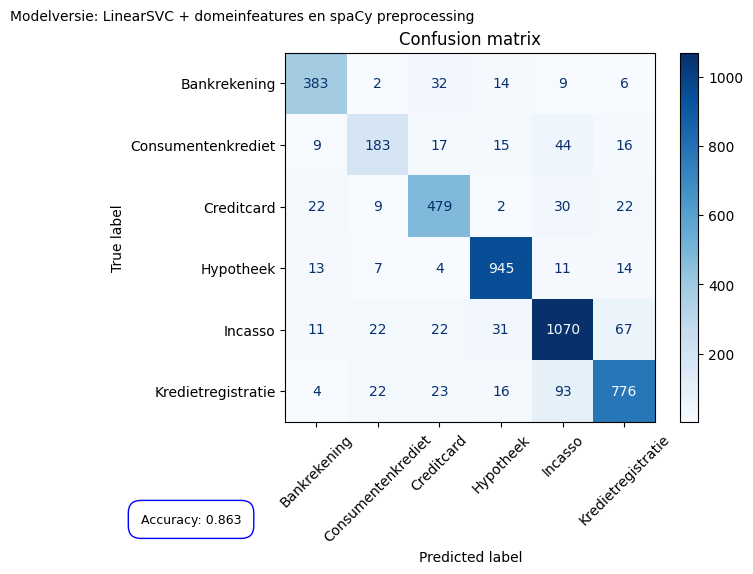

In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: LinearSVC + domeinfeatures en spaCy preprocessing", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {acc:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_spaCy_linsvc_met_domeinfeatures.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()